# Box-Cox Transformation

Box-Cox Transformation is a statistical transformation technique used to reduce skewness and make a numerical feature more normally distributed.

It applies a power transformation to the data.

The transformation is controlled by a parameter called **lambda (λ)**.

The general idea is:

- Find the best λ value.
- Apply the corresponding power transformation.
- Reduce skewness.
- Make the distribution closer to a normal distribution.

Box-Cox Transformation can only be applied to **strictly positive values**.

## Why Do We Need Box-Cox Transformation?

Many statistical and machine learning techniques work better when numerical features are approximately normally distributed.

Real-world data can be:

- Right-skewed
- Left-skewed
- Highly asymmetric

Box-Cox Transformation attempts to find a suitable power transformation that makes the distribution more symmetric.

In [1]:
import pandas as pd

df = pd.DataFrame({
    "Income": [
        20000,
        25000,
        30000,
        40000,
        50000,
        70000,
        100000,
        150000,
        250000,
        500000
    ]
})

df

,Income
0,20000
1,25000
2,30000
3,40000
4,50000
5,70000
6,100000
7,150000
8,250000
9,500000


In [2]:
print("Original Skewness:")
print(df["Income"].skew())

Original Skewness:
2.1005700604742


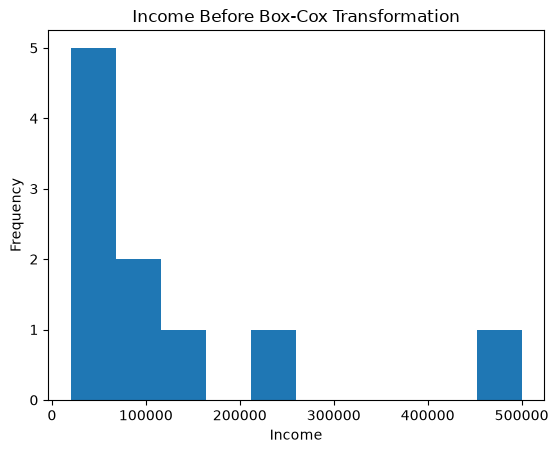

In [3]:
import matplotlib.pyplot as plt

plt.hist(df["Income"], bins=10)

plt.title("Income Before Box-Cox Transformation")
plt.xlabel("Income")
plt.ylabel("Frequency")

plt.show()

## Box-Cox Formula

For λ ≠ 0:

y(λ) = (x^λ - 1) / λ

For λ = 0:

y(λ) = log(x)

The value of λ determines which power transformation is applied.

Common values include:

λ = 1     → approximately no transformation

λ = 0.5   → approximately square root transformation

λ = 0     → logarithmic transformation

λ = -1    → approximately reciprocal transformation

Box-Cox automatically searches for a suitable λ value.

In [4]:
from scipy.stats import boxcox

transformed, lambda_value = boxcox(
    df["Income"]
)

lambda_value

np.float64(-0.3215779649185236)

In [5]:
df["Income_BoxCox"] = transformed

df

,Income,Income_BoxCox
0,20000,2.980960
1,25000,2.989872
2,30000,2.996694
3,40000,3.006676
4,50000,3.013808
5,70000,3.023638
6,100000,3.032961
7,150000,3.042338
8,250000,3.052537
9,500000,3.063952


In [6]:
print("Original Skewness:")
print(df["Income"].skew())

print("\nBox-Cox Skewness:")
print(df["Income_BoxCox"].skew())

Original Skewness:
2.1005700604742

Box-Cox Skewness:
0.15535361859659164


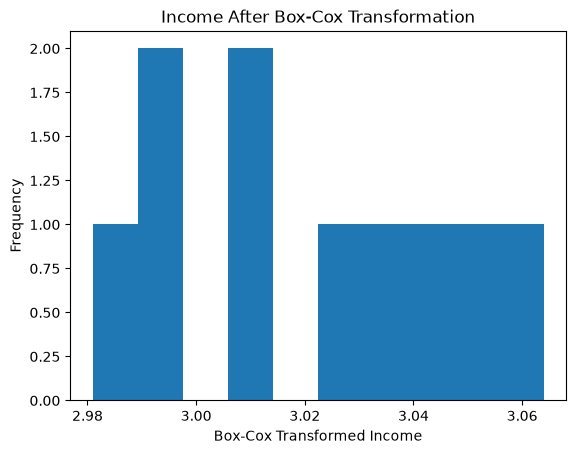

In [7]:
plt.hist(df["Income_BoxCox"], bins=10)

plt.title("Income After Box-Cox Transformation")
plt.xlabel("Box-Cox Transformed Income")
plt.ylabel("Frequency")

plt.show()

## Using Scikit-Learn

Scikit-learn provides `PowerTransformer`, which can perform Box-Cox transformation.

We specify:

`method="box-cox"`

The transformer estimates the appropriate λ value from the training data.

In [8]:
from sklearn.preprocessing import PowerTransformer

In [9]:
transformer = PowerTransformer(
    method="box-cox"
)

income_boxcox = transformer.fit_transform(
    df[["Income"]]
)

income_boxcox[:5]

array([[-1.50363888],
       [-1.16337971],
       [-0.90293292],
       [-0.521809  ],
       [-0.2495356 ]])

In [10]:
df["Income_BoxCox_Sklearn"] = income_boxcox

df

,Income,Income_BoxCox,Income_BoxCox_Sklearn
0,20000,2.980960,-1.503639
1,25000,2.989872,-1.163380
2,30000,2.996694,-0.902933
3,40000,3.006676,-0.521809
4,50000,3.013808,-0.249536
5,70000,3.023638,0.125792
6,100000,3.032961,0.481717
7,150000,3.042338,0.839722
8,250000,3.052537,1.229129
9,500000,3.063952,1.664936


In [11]:
print("Lambda:")
print(transformer.lambdas_)

Lambda:
[-0.32157796]
